# U-Net Segmentation: SAR Images & Brain MRI

This notebook implements U-Net from scratch in PyTorch for two tasks:
- **SAR Image Segmentation** (water segmentation, speckle noise)
- **Brain MRI Segmentation** (tumor detection, Gaussian noise)

### Notebook Structure
```
0. Setup & Imports
1. U-Net Architecture (shared by both tasks)
── SAR ──────────────────────────────────────
2. SAR Dataset & DataLoader
3. SAR Preprocessing  (Speckle Filter + Normalization)
4. SAR Quality Metrics (ENL, SSI, EPI, SSIM, PSNR)
5. SAR Training Loop   (BCE Loss)
6. SAR Evaluation & Visualization
── MRI ──────────────────────────────────────
7. MRI Dataset & DataLoader
8. MRI Preprocessing  (Gaussian Denoising + Normalization)
9. MRI Quality Metrics (SSIM, PSNR)
10. MRI Training Loop  (BCE Loss)
11. MRI Evaluation & Visualization
```

---
## 0. Setup & Imports

In [1]:
import torch

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

if DEVICE.type == 'cuda':
    gpu_name  = torch.cuda.get_device_name(0)
    gpu_mem   = torch.cuda.get_device_properties(0).total_memory / 1024**3
    print(f'✅ GPU detected  : {gpu_name}')
    print(f'   VRAM          : {gpu_mem:.1f} GB')
    print(f'   CUDA version  : {torch.version.cuda}')
    print(f'   PyTorch       : {torch.__version__}')

    torch.cuda.set_device(0)

    torch.backends.cudnn.benchmark = True
    torch.backends.cudnn.enabled   = True

else:
    print('No GPU found running on CPU.')

print(f'\n→ DEVICE set to: {DEVICE}')

✅ GPU detected  : NVIDIA GeForce RTX 3060 Laptop GPU
   VRAM          : 6.0 GB
   CUDA version  : 12.1
   PyTorch       : 2.5.1+cu121

→ DEVICE set to: cuda


In [2]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF

import tifffile
import cv2
from skimage.metrics import structural_similarity as skimage_ssim
from skimage.metrics import peak_signal_noise_ratio as skimage_psnr
from skimage.restoration import denoise_nl_means, estimate_sigma

# Reproducibility 
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

Using device: cuda


In [3]:
SPLIT_DIR = r"C:\Users\LEGION\Desktop\Studies\Workshops\unit4\split" 
SAR_TRAIN_IMG   = Path(SPLIT_DIR) / 'SAR' / 'train' / 'images'
SAR_TRAIN_MASK  = Path(SPLIT_DIR) / 'SAR' / 'train' / 'masks'
SAR_VAL_IMG     = Path(SPLIT_DIR) / 'SAR' / 'val'   / 'images'
SAR_VAL_MASK    = Path(SPLIT_DIR) / 'SAR' / 'val'   / 'masks'
SAR_TEST_IMG    = Path(SPLIT_DIR) / 'SAR' / 'test'  / 'images'
SAR_TEST_MASK   = Path(SPLIT_DIR) / 'SAR' / 'test'  / 'masks'

MRI_TRAIN_IMG   = Path(SPLIT_DIR) / 'MRI' / 'train' / 'images'
MRI_TRAIN_MASK  = Path(SPLIT_DIR) / 'MRI' / 'train' / 'masks'
MRI_VAL_IMG     = Path(SPLIT_DIR) / 'MRI' / 'val'   / 'images'
MRI_VAL_MASK    = Path(SPLIT_DIR) / 'MRI' / 'val'   / 'masks'
MRI_TEST_IMG    = Path(SPLIT_DIR) / 'MRI' / 'test'  / 'images'
MRI_TEST_MASK   = Path(SPLIT_DIR) / 'MRI' / 'test'  / 'masks'

IMG_SIZE  = 256   # all images resized to 256×256
print('Paths configured.')

Paths configured.


---
## 1. U-Net Architecture

The same U-Net model is used for both SAR and MRI tasks.

```
Input
  │
  ├─ Encoder Block 1 (64)  ──────────────────────────┐ skip
  ├─ Encoder Block 2 (128) ─────────────────────┐ skip│
  ├─ Encoder Block 3 (256) ────────────────┐ skip│    │
  ├─ Encoder Block 4 (512) ──────────┐ skip│    │    │
  │                                   │    │    │    │
  └─ Bottleneck (1024)                │    │    │    │
                                       │    │    │    │
  ┌─ Decoder Block 4 (512) ◄──────────┘    │    │    │
  ├─ Decoder Block 3 (256) ◄───────────────┘    │    │
  ├─ Decoder Block 2 (128) ◄────────────────────┘    │
  ├─ Decoder Block 1 (64)  ◄─────────────────────────┘
  │
  └─ Output Conv 1×1 → sigmoid → binary mask
```

In [4]:
class DoubleConv(nn.Module):
    """Two consecutive Conv2d → BatchNorm → ReLU blocks."""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class EncoderBlock(nn.Module):
    """DoubleConv + MaxPool. Returns (pooled, skip)."""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = DoubleConv(in_ch, out_ch)
        self.pool = nn.MaxPool2d(2)

    def forward(self, x):
        skip = self.conv(x)
        return self.pool(skip), skip


class DecoderBlock(nn.Module):
    """Upsample + concatenate skip connection + DoubleConv."""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.up   = nn.ConvTranspose2d(in_ch, out_ch, kernel_size=2, stride=2)
        self.conv = DoubleConv(in_ch, out_ch)   # in_ch because skip doubles channels

    def forward(self, x, skip):
        x = self.up(x)
        # Pad if spatial dims differ (handles odd input sizes)
        if x.shape != skip.shape:
            x = TF.resize(x, skip.shape[-2:])
        x = torch.cat([skip, x], dim=1)
        return self.conv(x)


class UNet(nn.Module):
    """
    U-Net from scratch.
    in_channels : 1 for grayscale SAR/MRI, 3 for RGB
    out_channels: 1 for binary segmentation
    features    : channel sizes for the 4 encoder levels
    """
    def __init__(self, in_channels=1, out_channels=1, features=[64, 128, 256, 512]):
        super().__init__()
        self.encoders = nn.ModuleList()
        self.decoders = nn.ModuleList()

        # Encoder
        ch = in_channels
        for f in features:
            self.encoders.append(EncoderBlock(ch, f))
            ch = f

        # Bottleneck
        self.bottleneck = DoubleConv(features[-1], features[-1] * 2)

        # Decoder  (reversed features)
        for f in reversed(features):
            self.decoders.append(DecoderBlock(f * 2, f))

        # Final 1×1 conv
        self.final_conv = nn.Conv2d(features[0], out_channels, kernel_size=1)

    def forward(self, x):
        skips = []
        for enc in self.encoders:
            x, skip = enc(x)
            skips.append(skip)

        x = self.bottleneck(x)

        for dec, skip in zip(self.decoders, reversed(skips)):
            x = dec(x, skip)

        return torch.sigmoid(self.final_conv(x))

In [5]:
# ── Quick sanity check ────────────────────────────────────
model = UNet(in_channels=1, out_channels=1)
dummy = torch.randn(2, 1, 256, 256)          # batch=2, grayscale, 256×256
out   = model(dummy)
print(f'Input  shape : {dummy.shape}')
print(f'Output shape : {out.shape}')          # should be (2, 1, 256, 256)

total_params = sum(p.numel() for p in model.parameters())
print(f'Total params : {total_params:,}')

Input  shape : torch.Size([2, 1, 256, 256])
Output shape : torch.Size([2, 1, 256, 256])
Total params : 31,036,481


---
# PART 1 SAR Image Segmentation

## 2. SAR Dataset & DataLoader

In [6]:
class SARDataset(Dataset):
    """
    Loads SAR .tif image + binary mask pairs.
    apply_preprocessing=True  → speckle filter + normalize before returning
    apply_preprocessing=False → returns raw image (used for metric comparison)
    """
    def __init__(self, img_dir, mask_dir, img_size=256, apply_preprocessing=True, augment=False):
        self.img_paths   = sorted(Path(img_dir).glob('*.tif'))
        self.mask_dir    = Path(mask_dir)
        self.img_size    = img_size
        self.preprocess  = apply_preprocessing
        self.augment     = augment

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        img_path  = self.img_paths[idx]
        mask_name = f"{img_path.stem}_label{img_path.suffix}"
        mask_path = self.mask_dir / mask_name

        # Load
        img  = tifffile.imread(str(img_path)).astype(np.float32)
        mask = tifffile.imread(str(mask_path)).astype(np.float32)

        # Grayscale: take first channel if multi-band
        if img.ndim == 3:
            img = img[..., 0]
        if mask.ndim == 3:
            mask = mask[..., 0]

        # Resize
        img  = cv2.resize(img,  (self.img_size, self.img_size), interpolation=cv2.INTER_LINEAR)
        mask = cv2.resize(mask, (self.img_size, self.img_size), interpolation=cv2.INTER_NEAREST)

        # Preprocessing
        if self.preprocess:
            img = sar_speckle_filter(img)
            img = sar_normalize(img)

        # Binary mask
        mask = (mask > 0).astype(np.float32)

        # Augmentation (train only)
        if self.augment and random.random() > 0.5:
            img  = np.fliplr(img).copy()
            mask = np.fliplr(mask).copy()
        if self.augment and random.random() > 0.5:
            img  = np.flipud(img).copy()
            mask = np.flipud(mask).copy()

        # To tensor: add channel dim
        img  = torch.from_numpy(img).unsqueeze(0)   # (1, H, W)
        mask = torch.from_numpy(mask).unsqueeze(0)  # (1, H, W)
        return img, mask

In [7]:
BATCH_SIZE = 8

sar_train_ds = SARDataset(SAR_TRAIN_IMG, SAR_TRAIN_MASK)
sar_val_ds   = SARDataset(SAR_VAL_IMG,   SAR_VAL_MASK)
sar_test_ds  = SARDataset(SAR_TEST_IMG,  SAR_TEST_MASK)

sar_train_loader = DataLoader(sar_train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=True)
sar_val_loader   = DataLoader(sar_val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
sar_test_loader  = DataLoader(sar_test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

print(f'SAR — train: {len(sar_train_ds)} | val: {len(sar_val_ds)} | test: {len(sar_test_ds)}')

SAR — train: 1612 | val: 345 | test: 347


---
## 3. SAR Preprocessing  Speckle Filtering & Normalization

SAR images suffer from **speckle noise** a granular interference caused by coherent
illumination. It follows a **multiplicative** model: `noisy = clean × speckle`.

We apply two filters and compare them:
| Filter | Principle |
|--------|-----------|
| **Lee** | Adaptive weights local mean/variance. Preserves edges. |
| **Frost** | Exponential kernel weighted by local variance. Smooth + edge-aware. |

In [8]:
def lee_filter(img, kernel_size=7):
    """
    Lee adaptive speckle filter.
    Reduces multiplicative noise while preserving edges.
    """
    img = img.astype(np.float32)
    k   = kernel_size

    mean  = cv2.boxFilter(img, ddepth=-1, ksize=(k, k))
    mean2 = cv2.boxFilter(img**2, ddepth=-1, ksize=(k, k))
    var   = mean2 - mean**2

    # Estimate overall noise variance from homogeneous region
    noise_var = np.mean(var)
    noise_var = max(noise_var, 1e-6)

    # Lee weight: 0 in smooth regions (trust mean), 1 in textured regions (trust pixel)
    weight  = var / (var + noise_var)
    filtered = mean + weight * (img - mean)
    return filtered.astype(np.float32)


def frost_filter(img, kernel_size=7, damping=2.0):
    """
    Frost adaptive speckle filter.
    Uses exponential decay kernel weighted by local coefficient of variation.
    """
    img = img.astype(np.float32)
    k   = kernel_size
    half = k // 2

    rows, cols = img.shape
    filtered   = np.zeros_like(img)

    # Distance map from center of kernel
    y, x = np.mgrid[-half:half+1, -half:half+1]
    dist = np.sqrt(x**2 + y**2)

    padded = np.pad(img, half, mode='reflect')

    for i in range(rows):
        for j in range(cols):
            patch = padded[i:i+k, j:j+k]
            mu    = np.mean(patch)
            sigma = np.std(patch)
            cv    = sigma / (mu + 1e-6)   # coefficient of variation
            # Exponential kernel: decays faster in textured regions
            kernel  = np.exp(-damping * cv * dist)
            kernel /= kernel.sum()
            filtered[i, j] = np.sum(kernel * patch)

    return filtered.astype(np.float32)


def sar_speckle_filter(img, method='lee', kernel_size=7):
    """Apply chosen speckle filter. Default: Lee."""
    if method == 'lee':
        return lee_filter(img, kernel_size)
    elif method == 'frost':
        return frost_filter(img, kernel_size)
    else:
        raise ValueError(f'Unknown method: {method}. Choose lee or frost.')


def sar_normalize(img):
    """Min-max normalize SAR image to [0, 1]."""
    mn, mx = img.min(), img.max()
    if mx - mn < 1e-6:
        return np.zeros_like(img)
    return (img - mn) / (mx - mn)

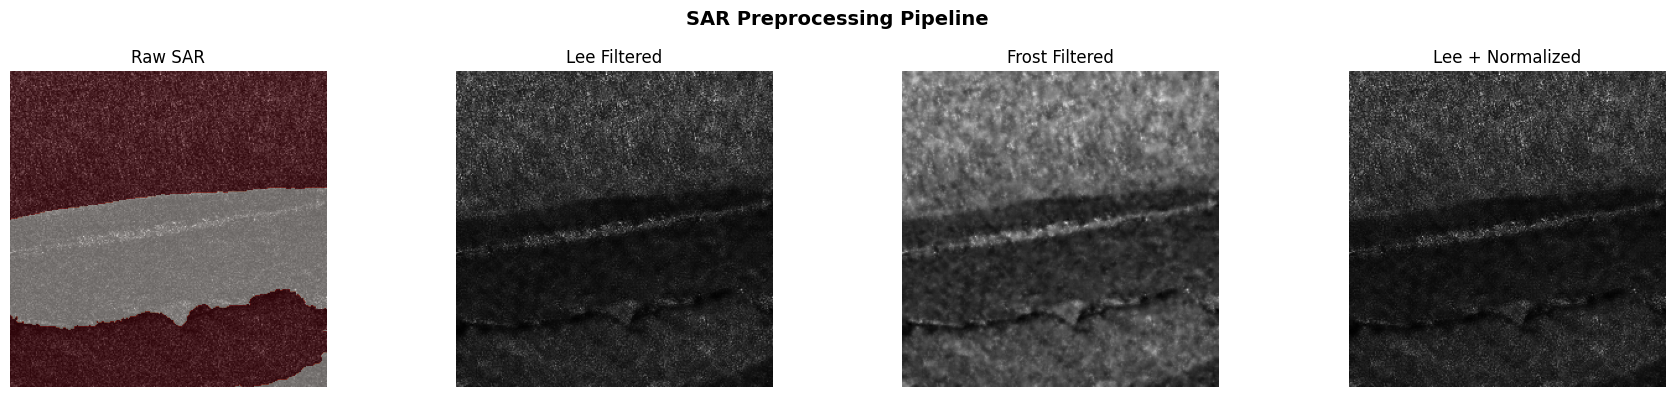

In [9]:
# ── Visualize preprocessing on one sample ─────────────────
raw_ds = SARDataset(SAR_TRAIN_IMG, SAR_TRAIN_MASK, apply_preprocessing=False)
raw_img, raw_mask = raw_ds[0]
raw_np  = raw_img.squeeze().numpy()

lee_filtered   = lee_filter(raw_np)
frost_filtered = frost_filter(raw_np)
lee_norm       = sar_normalize(lee_filtered)

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
titles = ['Raw SAR', 'Lee Filtered', 'Frost Filtered', 'Lee + Normalized']
imgs   = [raw_np, lee_filtered, frost_filtered, lee_norm]

for ax, title, im in zip(axes, titles, imgs):
    ax.imshow(im, cmap='gray')
    ax.set_title(title, fontsize=12)
    ax.axis('off')

axes[0].imshow(raw_mask.squeeze(), cmap='Reds', alpha=0.4)
plt.suptitle('SAR Preprocessing Pipeline', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

- **ENL (Equivalent Number of Looks):** Measures speckle reduction; higher values indicate smoother images. 

- **SSI (Speckle Suppression Index):** Measures remaining noise after filtering; lower values are better. 

- **EPI (Edge Preservation Index):** Evaluates how well image edges are preserved; higher is better. 

- **SSIM (Structural Similarity Index):** Measures perceptual similarity to the reference image; higher values indicate better similarity. 

- **PSNR (Peak Signal-to-Noise Ratio):** Evaluates pixel-level reconstruction quality in dB; higher values mean better fidelity. 

In [10]:
def compute_enl(img):
    """
    Equivalent Number of Looks.
    ENL = (mean / std)^2 in a homogeneous region.
    Higher ENL → less speckle.
    We use the full image as proxy (works for comparative evaluation).
    """
    mu  = np.mean(img)
    std = np.std(img)
    return (mu / (std + 1e-6)) ** 2


def compute_ssi(noisy, filtered):
    """
    Speckle Suppression Index.
    SSI = std(filtered) / std(noisy)
    SSI < 1 means speckle was suppressed.
    """
    return np.std(filtered) / (np.std(noisy) + 1e-6)


def compute_epi(noisy, filtered, ksize=3):
    """
    Edge Preservation Index.
    EPI = correlation between Laplacian edges of original and filtered.
    Range [0, 1]. EPI → 1 means edges perfectly preserved.
    """
    def edges(im):
        im8 = cv2.normalize(im, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
        return cv2.Laplacian(im8, cv2.CV_64F)

    e_noisy    = edges(noisy).flatten()
    e_filtered = edges(filtered).flatten()

    corr = np.corrcoef(e_noisy, e_filtered)[0, 1]
    return float(np.clip(corr, 0, 1))


def compute_ssim(img1, img2):
    """Structural Similarity Index. Range [-1, 1]; 1 = identical."""
    data_range = max(img1.max(), img2.max()) - min(img1.min(), img2.min())
    return skimage_ssim(img1, img2, data_range=data_range)


def compute_psnr(original, processed):
    """Peak Signal-to-Noise Ratio in dB."""
    data_range = original.max() - original.min()
    return skimage_psnr(original, processed, data_range=data_range)


def evaluate_preprocessing(raw, filtered, label='Lee Filter'):
    """Print a full quality report comparing raw vs filtered SAR."""
    enl_raw  = compute_enl(raw)
    enl_filt = compute_enl(filtered)
    ssi      = compute_ssi(raw, filtered)
    epi      = compute_epi(raw, filtered)
    ssim_val = compute_ssim(raw, filtered)
    psnr_val = compute_psnr(raw, filtered)

    print(f'\n── Quality Metrics: {label} ──────────────')
    print(f'  ENL  raw      : {enl_raw:.2f}')
    print(f'  ENL  filtered : {enl_filt:.2f}  (↑ means less speckle)')
    print(f'  SSI           : {ssi:.4f}     (↓ < 1 = speckle suppressed)')
    print(f'  EPI           : {epi:.4f}     (↑ → 1 = edges preserved)')
    print(f'  SSIM          : {ssim_val:.4f}     (↑ → 1 = structural similarity)')
    print(f'  PSNR          : {psnr_val:.2f} dB  (↑ = better fidelity)')
    return dict(ENL_raw=enl_raw, ENL_filtered=enl_filt, SSI=ssi, EPI=epi, SSIM=ssim_val, PSNR=psnr_val)


── Quality Metrics: Lee Filter ──────────────
  ENL  raw      : 2.97
  ENL  filtered : 5.98  (↑ means less speckle)
  SSI           : 0.7050     (↓ < 1 = speckle suppressed)
  EPI           : 0.9704     (↑ → 1 = edges preserved)
  SSIM          : 0.7876     (↑ → 1 = structural similarity)
  PSNR          : 27.52 dB  (↑ = better fidelity)

── Quality Metrics: Frost Filter ──────────────
  ENL  raw      : 2.97
  ENL  filtered : 9.78  (↑ means less speckle)
  SSI           : 0.5507     (↓ < 1 = speckle suppressed)
  EPI           : 0.8768     (↑ → 1 = edges preserved)
  SSIM          : 0.4148     (↑ → 1 = structural similarity)
  PSNR          : 22.45 dB  (↑ = better fidelity)


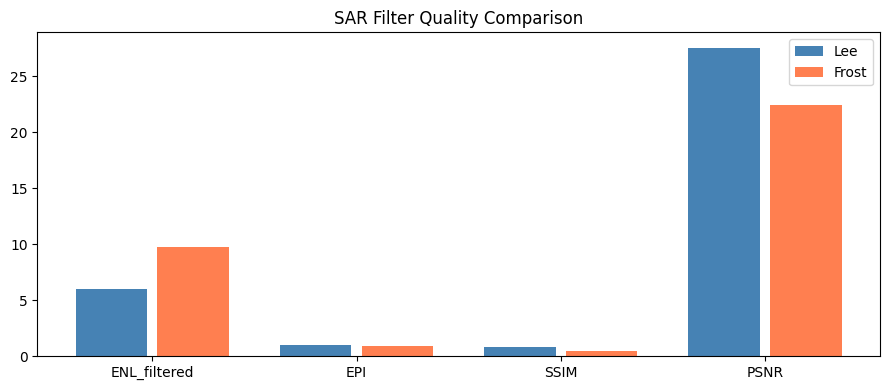

In [11]:
# Evaluate on the sample image 
metrics_lee   = evaluate_preprocessing(raw_np, lee_filtered,   label='Lee Filter')
metrics_frost = evaluate_preprocessing(raw_np, frost_filtered, label='Frost Filter')

# Bar chart comparison 
metric_names = ['ENL_filtered', 'EPI', 'SSIM', 'PSNR']
lee_vals   = [metrics_lee[m]   for m in metric_names]
frost_vals = [metrics_frost[m] for m in metric_names]

x = np.arange(len(metric_names))
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(x - 0.2, lee_vals,   width=0.35, label='Lee',   color='steelblue')
ax.bar(x + 0.2, frost_vals, width=0.35, label='Frost', color='coral')
ax.set_xticks(x)
ax.set_xticklabels(metric_names)
ax.set_title('SAR Filter Quality Comparison')
ax.legend()
plt.tight_layout()
plt.show()

---
## 5. SAR Training Loop BCE Loss

In [12]:
def dice_coefficient(pred, target, threshold=0.5, eps=1e-6):
    """Dice = 2|A∩B| / (|A|+|B|). Ranges [0,1]; 1 is perfect."""
    pred_bin = (pred > threshold).float()
    intersection = (pred_bin * target).sum()
    return (2 * intersection + eps) / (pred_bin.sum() + target.sum() + eps)


def iou_score(pred, target, threshold=0.5, eps=1e-6):
    """Intersection over Union."""
    pred_bin = (pred > threshold).float()
    inter    = (pred_bin * target).sum()
    union    = pred_bin.sum() + target.sum() - inter
    return (inter + eps) / (union + eps)


def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, total_dice = 0, 0
    for imgs, masks in loader:
        imgs, masks = imgs.to(device), masks.to(device)
        preds = model(imgs)
        loss  = criterion(preds, masks)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        total_dice += dice_coefficient(preds, masks).item()
    n = len(loader)
    return total_loss / n, total_dice / n


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, total_dice, total_iou = 0, 0, 0
    for imgs, masks in loader:
        imgs, masks = imgs.to(device), masks.to(device)
        preds = model(imgs)
        total_loss += criterion(preds, masks).item()
        total_dice += dice_coefficient(preds, masks).item()
        total_iou  += iou_score(preds, masks).item()
    n = len(loader)
    return total_loss / n, total_dice / n, total_iou / n


def train_model(model, train_loader, val_loader, epochs, lr, device,
                model_name='model', patience=10):
    criterion = nn.BCELoss()              # Binary Cross Entropy
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)

    history = {'train_loss': [], 'val_loss': [], 'train_dice': [], 'val_dice': []}
    best_val_loss  = float('inf')
    patience_count = 0

    for epoch in range(1, epochs + 1):
        tr_loss, tr_dice = train_one_epoch(model, train_loader, optimizer, criterion, device)
        vl_loss, vl_dice, vl_iou = evaluate(model, val_loader, criterion, device)
        scheduler.step(vl_loss)

        history['train_loss'].append(tr_loss)
        history['val_loss'].append(vl_loss)
        history['train_dice'].append(tr_dice)
        history['val_dice'].append(vl_dice)

        print(f'Epoch [{epoch:03d}/{epochs}]  '
              f'Train Loss: {tr_loss:.4f}  Dice: {tr_dice:.4f}  |  '
              f'Val Loss: {vl_loss:.4f}  Dice: {vl_dice:.4f}  IoU: {vl_iou:.4f}')

        # Save best
        if vl_loss < best_val_loss:
            best_val_loss  = vl_loss
            patience_count = 0
            torch.save(model.state_dict(), f'{model_name}_best.pth')
        else:
            patience_count += 1
            if patience_count >= patience:
                print(f'Early stopping at epoch {epoch}.')
                break

    return history

In [13]:
torch.cuda.empty_cache()

In [14]:
# Instantiate and train SAR model 
SAR_EPOCHS = 60
SAR_LR     = 1e-4

sar_model = UNet(in_channels=1, out_channels=1).to(DEVICE)
print(f"Model is on: {next(sar_model.parameters()).device}")
# should print: cuda:0
sar_history = train_model(
    model        = sar_model,
    train_loader = sar_train_loader,
    val_loader   = sar_val_loader,
    epochs       = SAR_EPOCHS,
    lr           = SAR_LR,
    device       = DEVICE,
    model_name   = 'sar_unet',
    patience     = 10
)

Model is on: cuda:0
Epoch [001/60]  Train Loss: 0.5463  Dice: 0.5953  |  Val Loss: 0.4725  Dice: 0.6313  IoU: 0.4921
Epoch [002/60]  Train Loss: 0.4556  Dice: 0.6607  |  Val Loss: 0.5408  Dice: 0.5792  IoU: 0.4330
Epoch [003/60]  Train Loss: 0.4203  Dice: 0.6776  |  Val Loss: 0.4232  Dice: 0.6385  IoU: 0.5022
Epoch [004/60]  Train Loss: 0.3945  Dice: 0.7070  |  Val Loss: 0.3377  Dice: 0.6696  IoU: 0.5223
Epoch [005/60]  Train Loss: 0.3774  Dice: 0.7176  |  Val Loss: 0.4881  Dice: 0.5572  IoU: 0.4142
Epoch [006/60]  Train Loss: 0.3538  Dice: 0.7449  |  Val Loss: 0.3862  Dice: 0.6578  IoU: 0.5186
Epoch [007/60]  Train Loss: 0.3540  Dice: 0.7430  |  Val Loss: 0.2618  Dice: 0.7831  IoU: 0.6700
Epoch [008/60]  Train Loss: 0.3264  Dice: 0.7692  |  Val Loss: 0.2847  Dice: 0.7737  IoU: 0.6604
Epoch [009/60]  Train Loss: 0.3130  Dice: 0.7790  |  Val Loss: 0.4311  Dice: 0.6753  IoU: 0.5460
Epoch [010/60]  Train Loss: 0.2980  Dice: 0.7923  |  Val Loss: 0.3791  Dice: 0.7056  IoU: 0.5818
Epoch [011

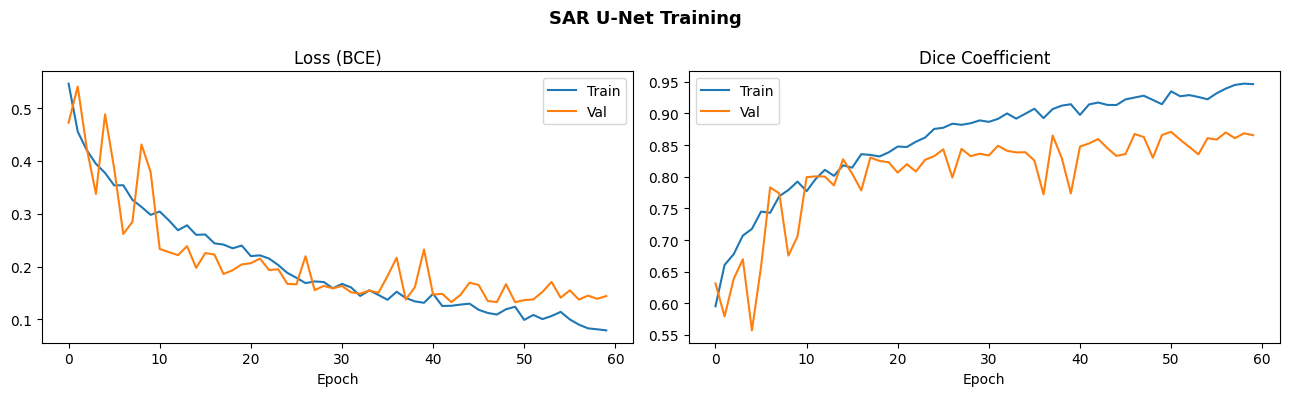

In [15]:
# Plot training curves 
def plot_history(history, title):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
    ax1.plot(history['train_loss'], label='Train')
    ax1.plot(history['val_loss'],   label='Val')
    ax1.set_title('Loss (BCE)')
    ax1.set_xlabel('Epoch')
    ax1.legend()

    ax2.plot(history['train_dice'], label='Train')
    ax2.plot(history['val_dice'],   label='Val')
    ax2.set_title('Dice Coefficient')
    ax2.set_xlabel('Epoch')
    ax2.legend()

    plt.suptitle(title, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

plot_history(sar_history, 'SAR U-Net Training')

## 6. SAR Evaluation & Visualization

In [16]:
# Load best weights and evaluate on test set 
sar_model.load_state_dict(torch.load('sar_unet_best.pth', map_location=DEVICE))
criterion = nn.BCELoss()

test_loss, test_dice, test_iou = evaluate(sar_model, sar_test_loader, criterion, DEVICE)
print(f'SAR Test Results — Loss: {test_loss:.4f} | Dice: {test_dice:.4f} | IoU: {test_iou:.4f}')

C:\Users\LEGION\AppData\Local\Temp\ipykernel_21156\103402240.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  sar_model.load_state_dict(torch.load('sar_unet_best.pth', ma

SAR Test Results — Loss: 0.1992 | Dice: 0.8542 | IoU: 0.7646


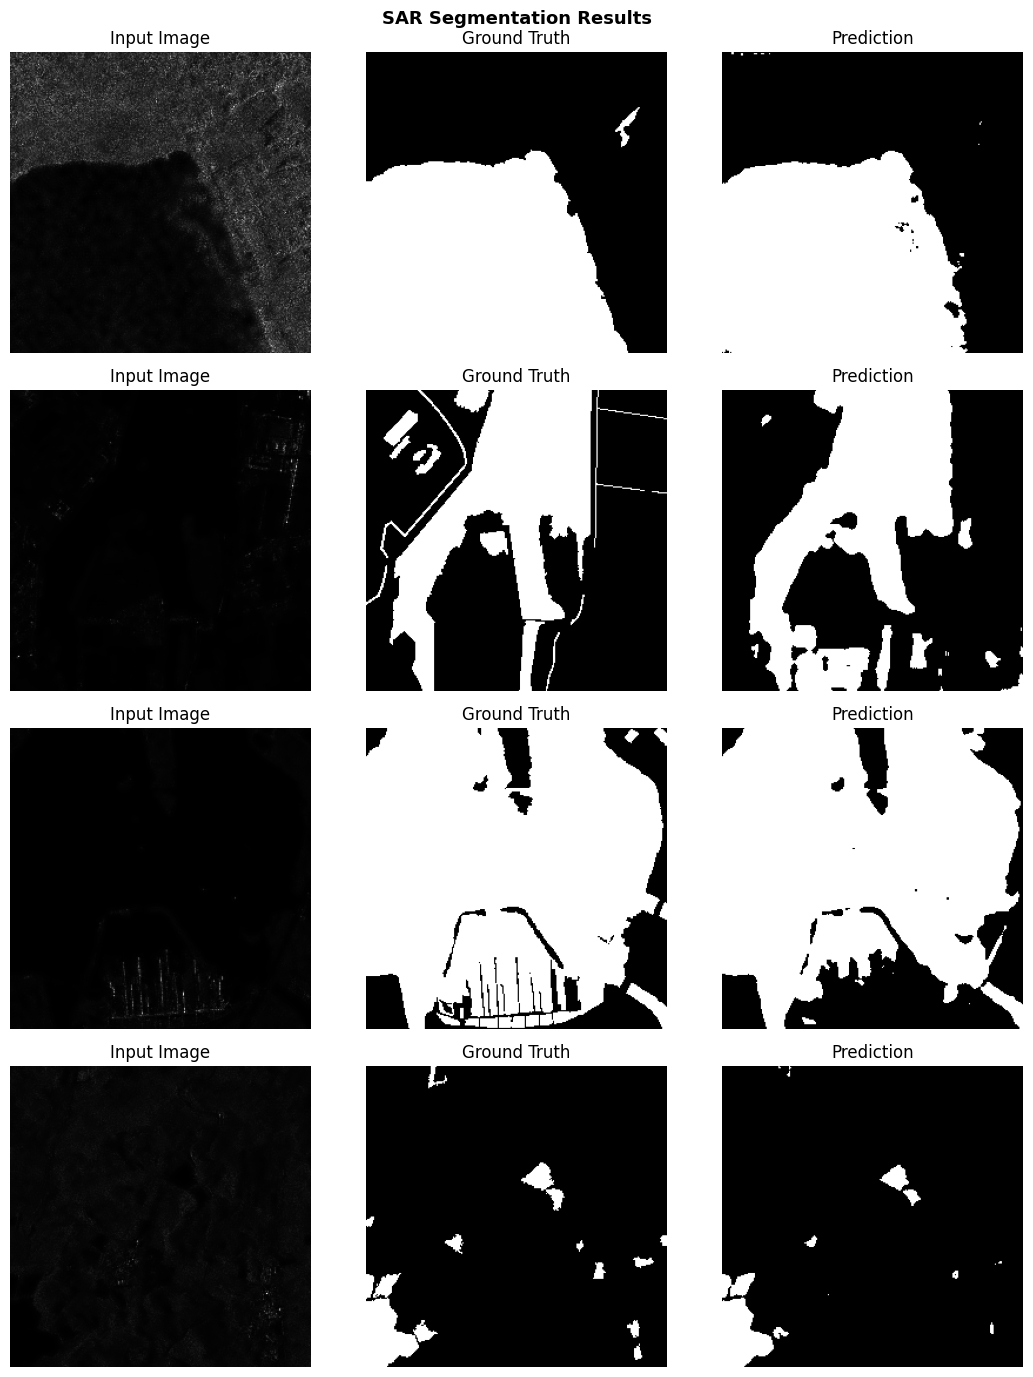

In [17]:
# Visualize predictions 
@torch.no_grad()
def visualize_predictions(model, dataset, device, n=4, title='Predictions'):
    model.eval()
    indices = random.sample(range(len(dataset)), n)
    fig, axes = plt.subplots(n, 3, figsize=(11, n * 3.5))

    for row, idx in enumerate(indices):
        img, mask = dataset[idx]
        pred = model(img.unsqueeze(0).to(device)).squeeze().cpu().numpy()

        axes[row, 0].imshow(img.squeeze(),      cmap='gray')
        axes[row, 0].set_title('Input Image')
        axes[row, 1].imshow(mask.squeeze(),     cmap='gray')
        axes[row, 1].set_title('Ground Truth')
        axes[row, 2].imshow(pred > 0.5,         cmap='gray')
        axes[row, 2].set_title('Prediction')

        for ax in axes[row]:
            ax.axis('off')

    plt.suptitle(title, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

visualize_predictions(sar_model, sar_test_ds, DEVICE, n=4, title='SAR Segmentation Results')

---
# PART 2 Brain MRI Segmentation

Unlike SAR, brain MRI noise is **additive Gaussian** — it comes from thermal noise
in the scanner electronics. We use Gaussian denoising instead of speckle filtering.

## 7. MRI Dataset & DataLoader

In [18]:
class MRIDataset(Dataset):
    """
    Loads brain MRI .tif image + _mask.tif pairs.
    Mask file = same name as image but with _mask suffix.
    """
    def __init__(self, img_dir, mask_dir, img_size=256, apply_preprocessing=True, augment=False):
        self.img_paths  = sorted(Path(img_dir).glob('*.tif'))
        self.mask_dir   = Path(mask_dir)
        self.img_size   = img_size
        self.preprocess = apply_preprocessing
        self.augment    = augment

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        img_path  = self.img_paths[idx]
        # mask name: replace last occurrence of .tif with _mask.tif
        mask_name = img_path.stem + '_mask.tif'
        mask_path = self.mask_dir / mask_name

        img  = tifffile.imread(str(img_path)).astype(np.float32)
        mask = tifffile.imread(str(mask_path)).astype(np.float32)

        # Use only one channel
        if img.ndim == 3:
            img = img[..., 0]
        if mask.ndim == 3:
            mask = (mask.sum(-1) > 0).astype(np.float32)

        # Resize
        img  = cv2.resize(img,  (self.img_size, self.img_size), interpolation=cv2.INTER_LINEAR)
        mask = cv2.resize(mask, (self.img_size, self.img_size), interpolation=cv2.INTER_NEAREST)

        # Preprocessing
        if self.preprocess:
            img = mri_gaussian_denoise(img)
            img = mri_normalize(img)

        mask = (mask > 0).astype(np.float32)

        # Augmentation
        if self.augment and random.random() > 0.5:
            img  = np.fliplr(img).copy()
            mask = np.fliplr(mask).copy()
        if self.augment and random.random() > 0.5:
            img  = np.rot90(img).copy()
            mask = np.rot90(mask).copy()

        img  = torch.from_numpy(img).unsqueeze(0)
        mask = torch.from_numpy(mask).unsqueeze(0)
        return img, mask

In [19]:
mri_train_ds = MRIDataset(MRI_TRAIN_IMG, MRI_TRAIN_MASK, augment=True)
mri_val_ds   = MRIDataset(MRI_VAL_IMG,   MRI_VAL_MASK)
mri_test_ds  = MRIDataset(MRI_TEST_IMG,  MRI_TEST_MASK)

mri_train_loader = DataLoader(mri_train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=True)
mri_val_loader   = DataLoader(mri_val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
mri_test_loader  = DataLoader(mri_test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

print(f'MRI — train: {len(mri_train_ds)} | val: {len(mri_val_ds)} | test: {len(mri_test_ds)}')

MRI — train: 2719 | val: 621 | test: 589


---
## 8. MRI Preprocessing Gaussian Denoising & Normalization

MRI noise model: `noisy = clean + ε`,  where `ε ~ N(0, σ²)` (additive Gaussian).

| Method | When to use |
|--------|-------------|
| **Gaussian Blur** | Simple, fast; best for light noise |
| **Non-Local Means (NLM)** | Slower but superior — preserves fine anatomical details |

In [20]:
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "PyWavelets", "-q"])
print("✅ PyWavelets installed — now restart kernel and rerun from MRI section")

✅ PyWavelets installed — now restart kernel and rerun from MRI section


In [21]:
def mri_gaussian_denoise(img, sigma=1.0):
    """
    Gaussian blur denoising.
    sigma controls smoothing strength: higher = more blur.
    """
    ksize = int(6 * sigma + 1) | 1    # ensure odd kernel size
    return cv2.GaussianBlur(img, (ksize, ksize), sigmaX=sigma)


def mri_nlm_denoise(img):
    """
    Non-Local Means denoising.
    Slower but preserves anatomical edges far better than Gaussian.
    Best for cases where tumor boundaries must stay sharp.
    """
    img_norm = cv2.normalize(img, None, 0, 1, cv2.NORM_MINMAX)
    sigma_est = np.mean(estimate_sigma(img_norm))
    denoised  = denoise_nl_means(img_norm, h=1.15 * sigma_est,
                                  fast_mode=True, patch_size=5, patch_distance=3)
    return denoised.astype(np.float32)


def mri_normalize(img):
    """
    Z-score normalization: (x - mean) / std → then clip to [-3, 3] and rescale to [0, 1].
    More robust for MRI than min-max because MRI intensity can have outliers.
    """
    mu  = np.mean(img)
    std = np.std(img) + 1e-6
    img = (img - mu) / std
    img = np.clip(img, -3, 3)
    img = (img + 3) / 6.0    # rescale to [0, 1]
    return img.astype(np.float32)

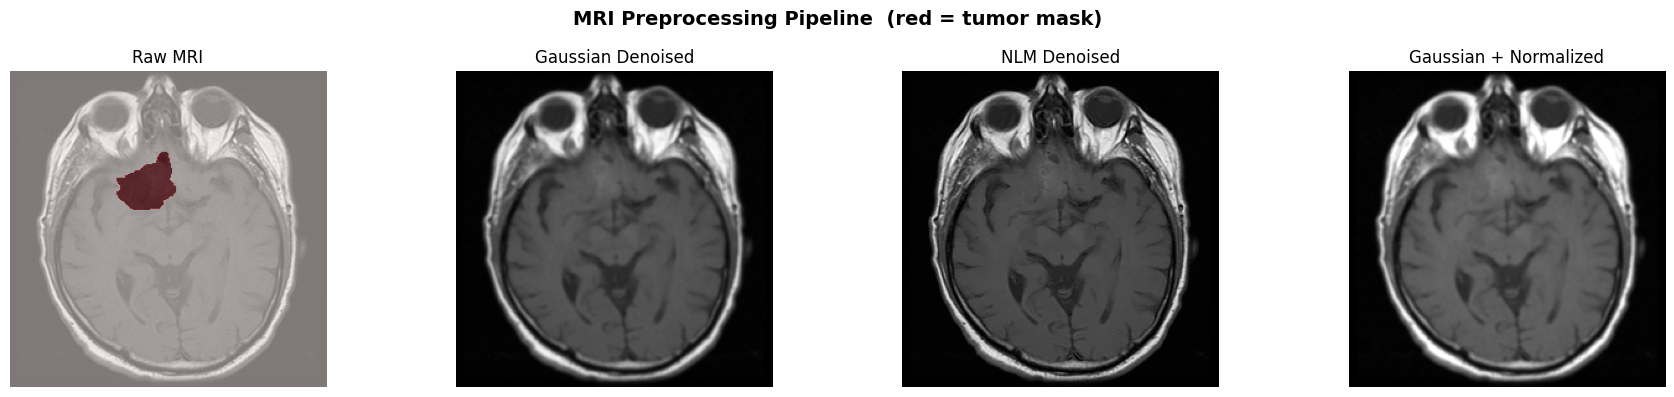

In [22]:
# Visualize MRI preprocessing 
raw_mri_ds = MRIDataset(MRI_TRAIN_IMG, MRI_TRAIN_MASK, apply_preprocessing=False)

# Pick a slice that has a tumor
for i in range(len(raw_mri_ds)):
    raw_mri, raw_mri_mask = raw_mri_ds[i]
    if raw_mri_mask.sum() > 0:
        break

raw_mri_np = raw_mri.squeeze().numpy()
gauss_den  = mri_gaussian_denoise(raw_mri_np)
nlm_den    = mri_nlm_denoise(raw_mri_np)
final_mri  = mri_normalize(gauss_den)

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
titles = ['Raw MRI', 'Gaussian Denoised', 'NLM Denoised', 'Gaussian + Normalized']
imgs   = [raw_mri_np, gauss_den, nlm_den, final_mri]

for ax, title, im in zip(axes, titles, imgs):
    ax.imshow(im, cmap='gray')
    ax.set_title(title, fontsize=12)
    ax.axis('off')

# Overlay tumor mask on raw
axes[0].imshow(raw_mri_mask.squeeze(), cmap='Reds', alpha=0.5)
plt.suptitle('MRI Preprocessing Pipeline  (red = tumor mask)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 9. MRI Quality Metrics

In [23]:
def evaluate_mri_preprocessing(raw, denoised, label='Gaussian'):
    """SSIM and PSNR are sufficient for MRI (no speckle-specific metrics needed)."""
    ssim_val = compute_ssim(raw, denoised)
    psnr_val = compute_psnr(raw, denoised)
    snr_raw  = np.mean(raw)  / (np.std(raw)  + 1e-6)
    snr_den  = np.mean(denoised) / (np.std(denoised) + 1e-6)

    print(f'\n── MRI Metrics: {label} ──────────────────')
    print(f'  SSIM : {ssim_val:.4f}   (↑ → 1 = structural similarity preserved)')
    print(f'  PSNR : {psnr_val:.2f} dB (↑ = better quality)')
    print(f'  SNR raw      : {snr_raw:.2f}')
    print(f'  SNR denoised : {snr_den:.2f}  (↑ means noise reduced)')
    return dict(SSIM=ssim_val, PSNR=psnr_val, SNR_raw=snr_raw, SNR_denoised=snr_den)

mri_metrics_gauss = evaluate_mri_preprocessing(raw_mri_np, gauss_den, label='Gaussian')
mri_metrics_nlm   = evaluate_mri_preprocessing(raw_mri_np, nlm_den,   label='NLM')


── MRI Metrics: Gaussian ──────────────────
  SSIM : 0.9304   (↑ → 1 = structural similarity preserved)
  PSNR : 29.49 dB (↑ = better quality)
  SNR raw      : 1.01
  SNR denoised : 1.07  (↑ means noise reduced)

── MRI Metrics: NLM ──────────────────
  SSIM : 0.1600   (↑ → 1 = structural similarity preserved)
  PSNR : 10.89 dB (↑ = better quality)
  SNR raw      : 1.01
  SNR denoised : 1.01  (↑ means noise reduced)


---
## 10. MRI Training Loop  BCE Loss

In [24]:
# ── Handle class imbalance: far more non-tumor pixels than tumor pixels ──
def compute_pos_weight(dataset, n_samples=200):
    """
    Estimate pos_weight for BCEWithLogitsLoss.
    pos_weight = #negative_pixels / #positive_pixels
    This corrects for the severe class imbalance in tumor segmentation.
    """
    pos, neg = 0, 0
    indices  = random.sample(range(len(dataset)), min(n_samples, len(dataset)))
    for i in indices:
        _, mask = dataset[i]
        pos += mask.sum().item()
        neg += (1 - mask).sum().item()
    weight = neg / (pos + 1e-6)
    print(f'Computed pos_weight: {weight:.2f}')
    return torch.tensor([weight])

pos_weight = compute_pos_weight(mri_train_ds).to(DEVICE)

# ── Weighted BCE ───────────────────────────────────────────
mri_criterion = nn.BCELoss()   # predictions already passed through sigmoid in UNet
# Alternative with logits (remove sigmoid from UNet.forward for this):
# mri_criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

Computed pos_weight: 112.49


Epoch [001/60]  Train Loss: 0.2968  Dice: 0.0138  |  Val Loss: 0.1939  Dice: 0.3974  IoU: 0.3974
Epoch [002/60]  Train Loss: 0.1653  Dice: 0.0093  |  Val Loss: 0.1250  Dice: 0.4103  IoU: 0.4103
Epoch [003/60]  Train Loss: 0.1103  Dice: 0.0270  |  Val Loss: 0.0901  Dice: 0.3974  IoU: 0.3974
Epoch [004/60]  Train Loss: 0.0802  Dice: 0.0994  |  Val Loss: 0.0695  Dice: 0.3974  IoU: 0.3974
Epoch [005/60]  Train Loss: 0.0619  Dice: 0.2266  |  Val Loss: 0.0544  Dice: 0.4095  IoU: 0.3650
Epoch [006/60]  Train Loss: 0.0500  Dice: 0.3474  |  Val Loss: 0.0437  Dice: 0.4149  IoU: 0.3984
Epoch [007/60]  Train Loss: 0.0426  Dice: 0.3392  |  Val Loss: 0.0462  Dice: 0.3210  IoU: 0.2703
Epoch [008/60]  Train Loss: 0.0372  Dice: 0.4018  |  Val Loss: 0.0331  Dice: 0.4928  IoU: 0.4569
Epoch [009/60]  Train Loss: 0.0346  Dice: 0.3967  |  Val Loss: 0.0273  Dice: 0.5539  IoU: 0.5151
Epoch [010/60]  Train Loss: 0.0309  Dice: 0.4380  |  Val Loss: 0.0277  Dice: 0.4990  IoU: 0.4587
Epoch [011/60]  Train Loss: 0.

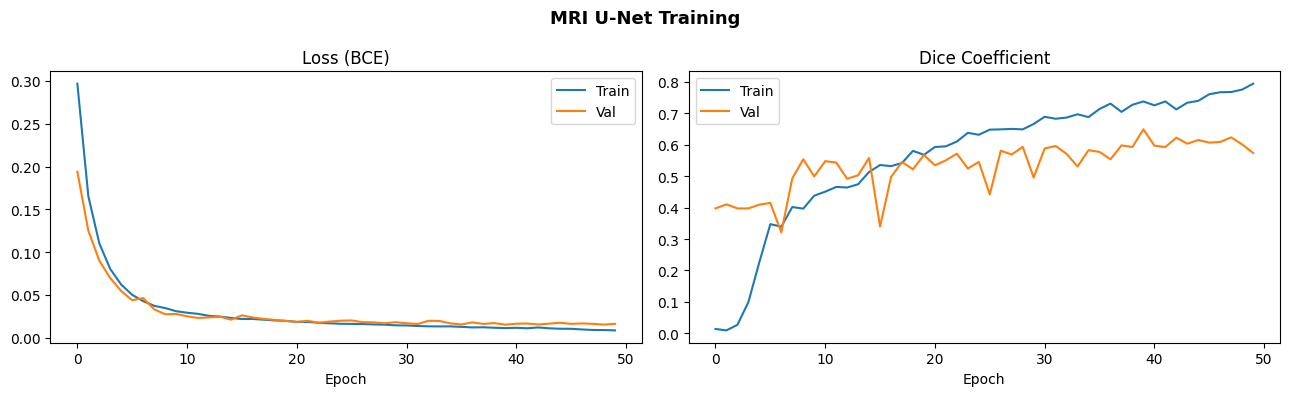

In [25]:
MRI_EPOCHS = 60
MRI_LR     = 1e-4

mri_model = UNet(in_channels=1, out_channels=1).to(DEVICE)

mri_history = train_model(
    model        = mri_model,
    train_loader = mri_train_loader,
    val_loader   = mri_val_loader,
    epochs       = MRI_EPOCHS,
    lr           = MRI_LR,
    device       = DEVICE,
    model_name   = 'mri_unet',
    patience     = 10
)

plot_history(mri_history, 'MRI U-Net Training')

---
## 11. MRI Evaluation & Visualization

In [26]:
mri_model.load_state_dict(torch.load('mri_unet_best.pth', map_location=DEVICE))

test_loss, test_dice, test_iou = evaluate(mri_model, mri_test_loader, mri_criterion, DEVICE)
print(f'MRI Test Results — Loss: {test_loss:.4f} | Dice: {test_dice:.4f} | IoU: {test_iou:.4f}')

C:\Users\LEGION\AppData\Local\Temp\ipykernel_21156\490810847.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  mri_model.load_state_dict(torch.load('mri_unet_best.pth', ma

MRI Test Results — Loss: 0.0270 | Dice: 0.4853 | IoU: 0.4401


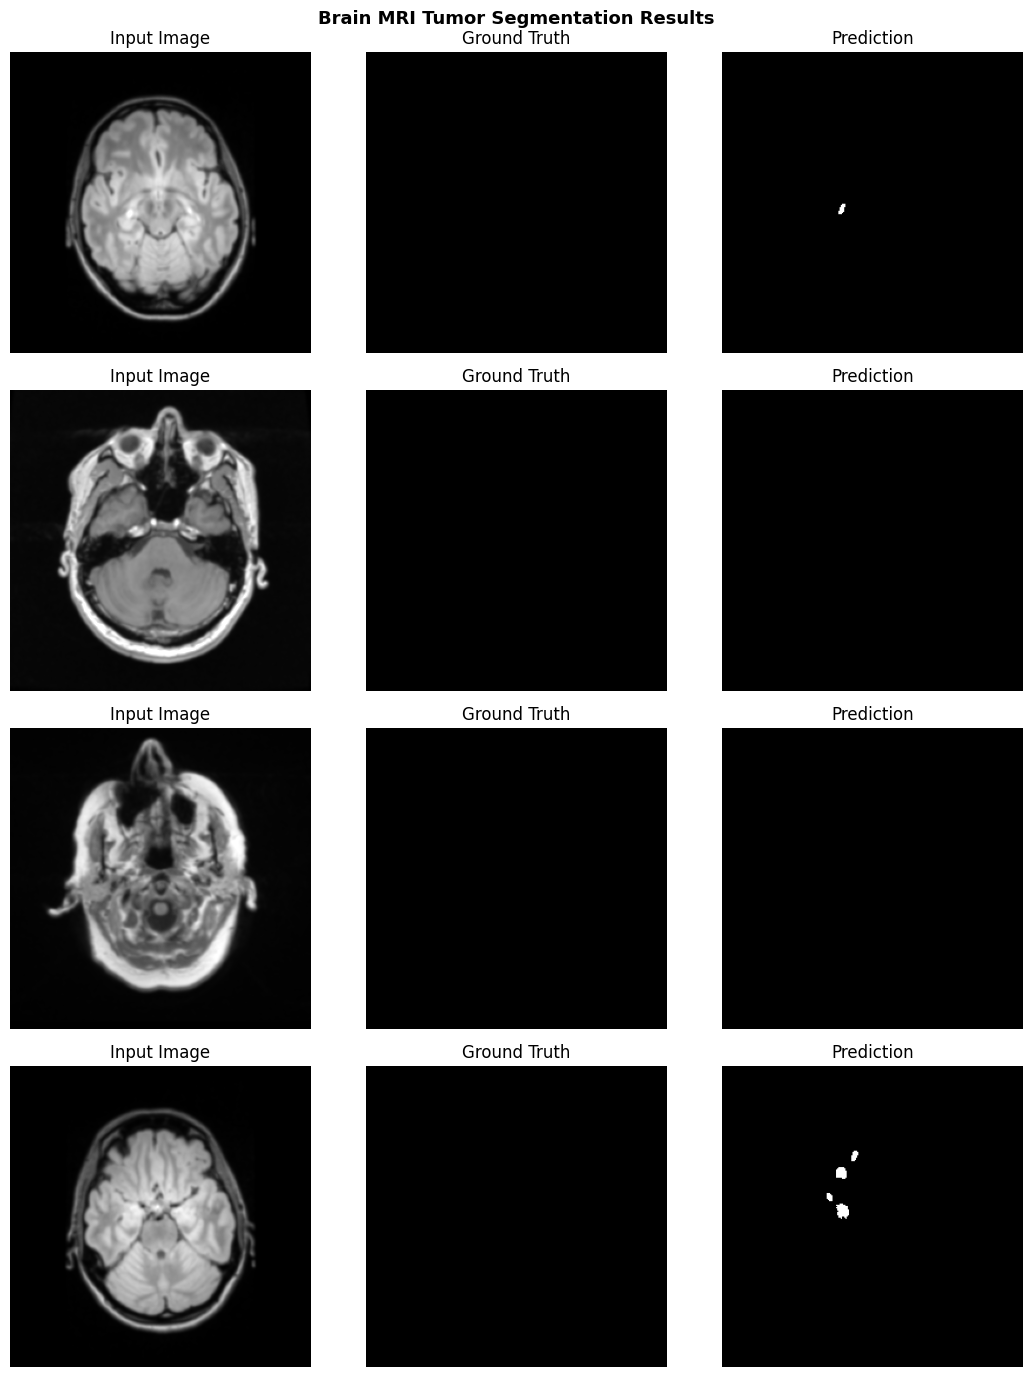

In [27]:
visualize_predictions(mri_model, mri_test_ds, DEVICE, n=4, title='Brain MRI Tumor Segmentation Results')

---
## Summary: SAR vs MRI Comparison

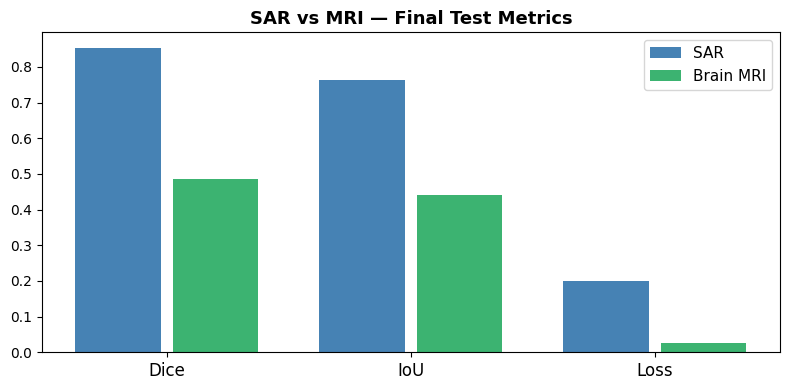

          FINAL TEST RESULTS
  SAR  — Dice: 0.8542  IoU: 0.7646  Loss: 0.1992
  MRI  — Dice: 0.4853  IoU: 0.4401  Loss: 0.0270


In [28]:
criterion = nn.BCELoss()

sar_loss, sar_dice, sar_iou = evaluate(sar_model, sar_test_loader, criterion, DEVICE)
mri_loss, mri_dice, mri_iou = evaluate(mri_model, mri_test_loader, criterion, DEVICE)

metrics = ['Dice', 'IoU', 'Loss']
sar_vals = [sar_dice, sar_iou, sar_loss]
mri_vals = [mri_dice, mri_iou, mri_loss]

x = np.arange(len(metrics))
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(x - 0.2, sar_vals, width=0.35, label='SAR',     color='steelblue')
ax.bar(x + 0.2, mri_vals, width=0.35, label='Brain MRI', color='mediumseagreen')
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=12)
ax.set_title('SAR vs MRI — Final Test Metrics', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

print('          FINAL TEST RESULTS')

print(f'  SAR  — Dice: {sar_dice:.4f}  IoU: {sar_iou:.4f}  Loss: {sar_loss:.4f}')
print(f'  MRI  — Dice: {mri_dice:.4f}  IoU: {mri_iou:.4f}  Loss: {mri_loss:.4f}')
